# Using Neurokit2 to process data

In [2]:
#%pip install neurokit2
import neurokit2 as nk
import pandas as pd

Processing data from the EmotiBit file and selecting a range

In [3]:
eda_file = r"data/2025-07-16_18-00-15-608675_EA.csv"
raw_data = pd.read_csv(eda_file)
df_min = raw_data["LocalTimestamp"].min() + 200
df_max = raw_data["LocalTimestamp"].max() - 300
df = raw_data[(raw_data["LocalTimestamp"]>df_min) & (raw_data["LocalTimestamp"]<df_max)]
df_ea = df["EA"]

Obtain basic EDA plot

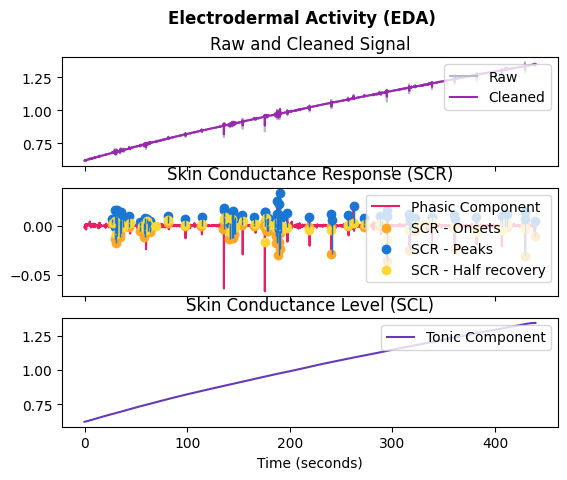

In [4]:
# raw eda signal
signals, info = nk.eda_process(df_ea, sampling_rate=15)

plt = nk.eda_plot(signals, info)

The processing function does two important things for our purpose: Firstly, it cleans the signal. Secondly, it detects the location of 1) peak onsets, 2) peak amplitude, and 3) half-recovery time. Let’s extract these from the output.

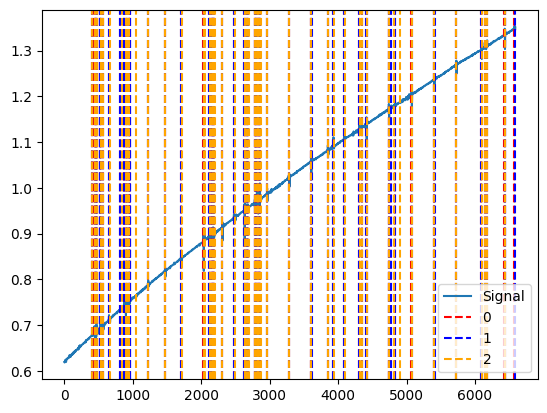

In [5]:
# Extract clean EDA and SCR features
cleaned = signals["EDA_Clean"]
features = [info["SCR_Onsets"], info["SCR_Peaks"], info["SCR_Recovery"]]

# Visualize SCR features in cleaned EDA signal
plot = nk.events_plot(features, cleaned, color=['red', 'blue', 'orange'])